# Análise e ajustes de modelos de série temporal com covariáveis

## Séries Temporais - A2

**Integrantes:**

- Gustavo Tironi
- Kauan Mariani Ferreira
- Lívia Verly
- Matheus Fillype Ferreira de Carvalho
- Pedro Henrique Coterli
- Sillas Rocha da Costa

## 0. Setup e carregamento dos dados

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [84]:
# Carregando os dados
data = pd.read_csv('data_updated.csv')
data['week'] = pd.to_datetime(data['week'])
data = data.set_index('week')

print(f"Período dos dados: {data.index.min()} até {data.index.max()}")
print(f"Total de observações: {len(data)}")
print(f"\nPrimeiras linhas:")
data.head(10)

Período dos dados: 2022-10-31 00:00:00 até 2025-10-27 00:00:00
Total de observações: 157

Primeiras linhas:


,volume,inv,users
week,,,
2022-10-31,0.38,1.609882,6.500
2022-11-07,0.47,1.880548,7.061
2022-11-14,0.32,2.297810,5.875
2022-11-21,1.69,5.623875,24.238
2022-11-28,1.23,1.473418,7.648
2022-12-05,0.77,0.691911,4.105
2022-12-12,0.49,0.335866,2.060
2022-12-19,0.14,0.182806,0.655
2022-12-26,0.39,0.182695,0.778


## 1. Análise exploratória multivariada e correlações

### 1.1. Visualização das séries

Nesta seção, realizaremos a análise exploratória dos dados com as variáveis `volume`, `inv` e `users`, a fim de identificar características que direcionem os modelos que serão ajustados.

Primeiramente, observemos o comportamento de cada série individualmente e em conjunto com suas versões normalizadas (cada série possui uma unidade de medida e uma escala diferentes).

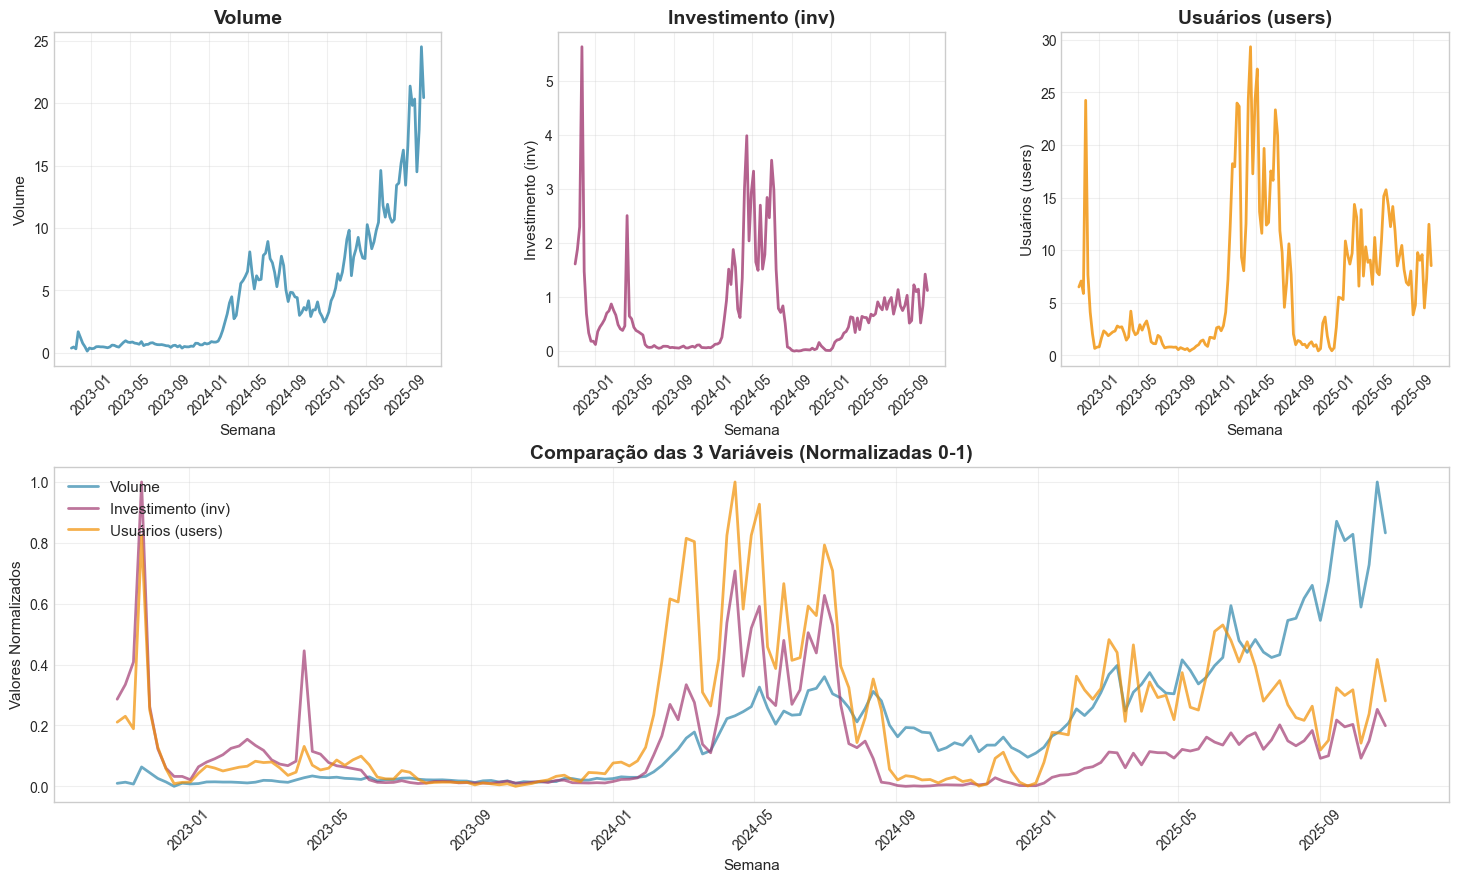

In [85]:
# Figura com 3 gráficos em cima e 1 embaixo
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Cores para cada variável
colors = {'volume': '#2E86AB', 'inv': '#A23B72', 'users': '#F18F01'}

# Gráficos individuais em cima (3 colunas)
variables = ['volume', 'inv', 'users']
titles = ['Volume', 'Investimento (inv)', 'Usuários (users)']

for i, (var, title) in enumerate(zip(variables, titles)):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(data.index, data[var], color=colors[var], linewidth=2, alpha=0.8)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Semana', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

# Gráfico combinado embaixo (ocupando as 3 colunas)
ax_combined = fig.add_subplot(gs[1, :])

# Normalizar os dados para plotar juntos (escala 0-1)
data_normalized = (data - data.min()) / (data.max() - data.min())

for var, title in zip(variables, titles):
    ax_combined.plot(data.index, data_normalized[var],
                     label=title, color=colors[var], linewidth=2, alpha=0.7)

ax_combined.set_title('Comparação das 3 Variáveis (Normalizadas 0-1)',
                      fontsize=14, fontweight='bold')
ax_combined.set_xlabel('Semana', fontsize=11)
ax_combined.set_ylabel('Valores Normalizados', fontsize=11)
ax_combined.legend(loc='upper left', fontsize=11)
ax_combined.grid(True, alpha=0.3)
ax_combined.tick_params(axis='x', rotation=45)

plt.show()

Como podemos ver, parece haver uma relação forte entre as covariáveis `users` e `inv`, com ambas seguindo o mesmo padrão, principalmente nos picos ocorridos em 2022 e na metade de 2024. Por outro lado, nossa variável target `volume` ou não corresponde a isso ou corresponde de forma mais suave. Além disso, ao final da série, vemos uma força de crescimento muito maior nessa variável do que nas outras.

### 1.2. Autocorrelação da variável target `volume`

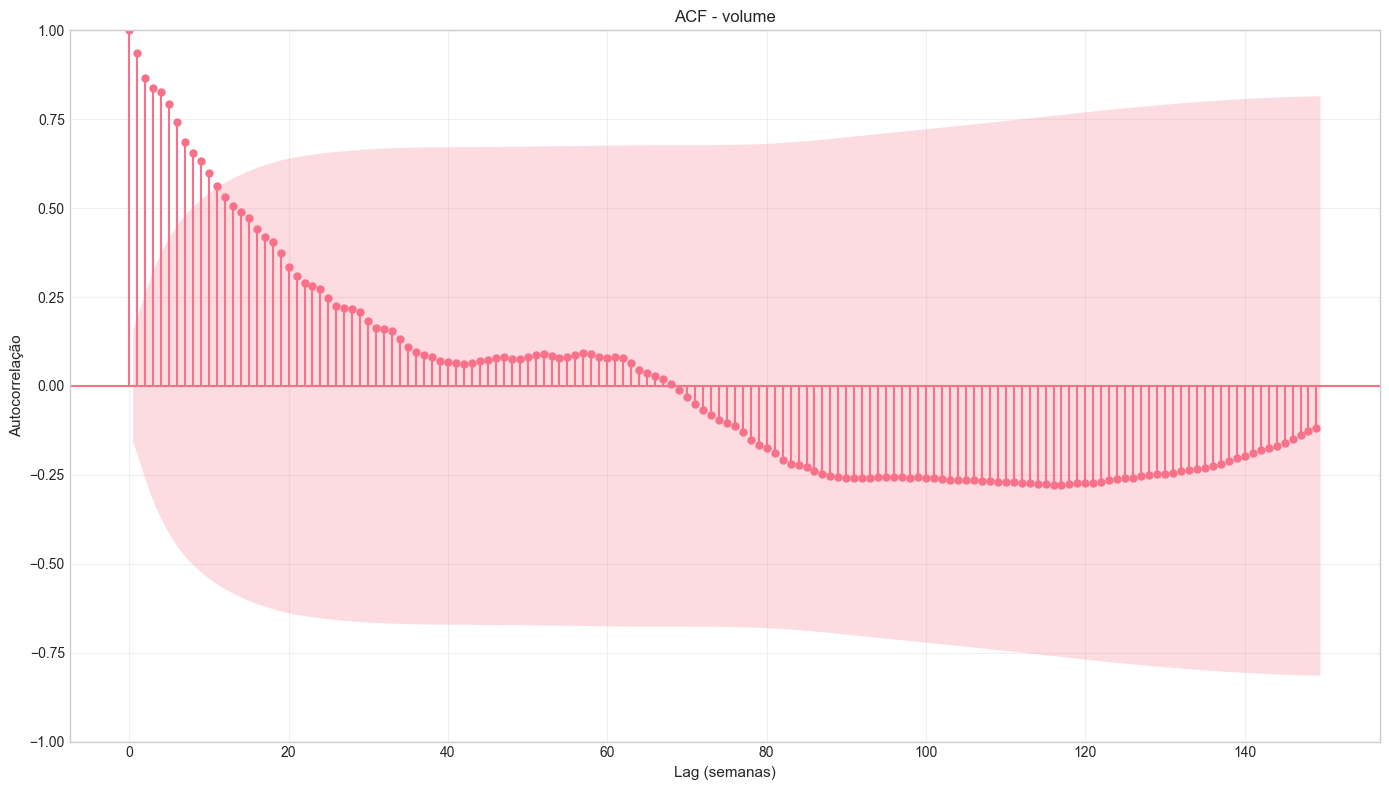

In [86]:
# Plotando a ACF da variável target
plot_acf(data["volume"], lags=149, alpha=0.05, title=f'ACF - volume')
plt.xlabel('Lag (semanas)', fontsize=11)
plt.ylabel('Autocorrelação', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ao analisar esse gráfico, vemos uma persistência significativa nos primeiros lags, com um decaimento suave característico de séries não-estacionárias com forte componente de tendência, sugerindo que a inércia da própria série é um componente preditivo essencial. Isso indica antecipadamente que os modelos baseados apenas em covariáveis externos (como o TSLM simples, que será analisado na seção 2) provavelmente deixarão autocorrelação residual, exigindo uma abordagem de regressão dinâmica para capturar essa estrutura de memória.

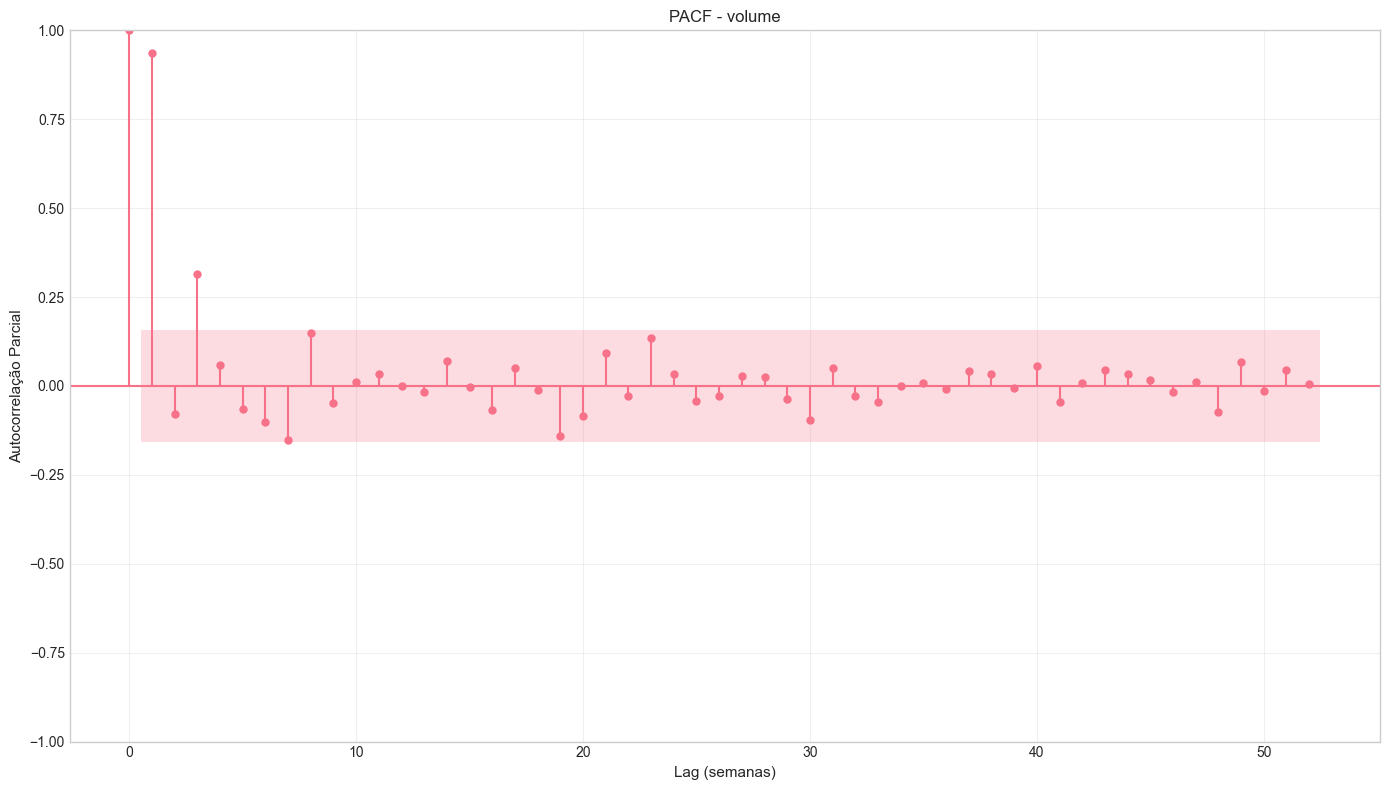

In [87]:
# Plotando a PACF da variável target
plot_pacf(data["volume"], lags=52, alpha=0.05, title=f'PACF - volume')
plt.xlabel('Lag (semanas)', fontsize=11)
plt.ylabel('Autocorrelação Parcial', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Já esse gráfico da PACF da target `volume` confirma a estrutura auto-regressiva dessa variável, com um corte de significância abrupto após o lag 1, o que sugere um processo gerador AR de ordem 1. Esses resultados serão utilizados para o ajuste dos modelos ARIMA na seção 4.

### 1.3. Teste de sazonalidade

A seguir, vamos realizar a decomposição STL da variável `volume` para verificar se existe alguma componente sazonal relevante. Para isso, faremos a decomposição com janelas de 4 semanas (mensal) e 52 semanas (anual).

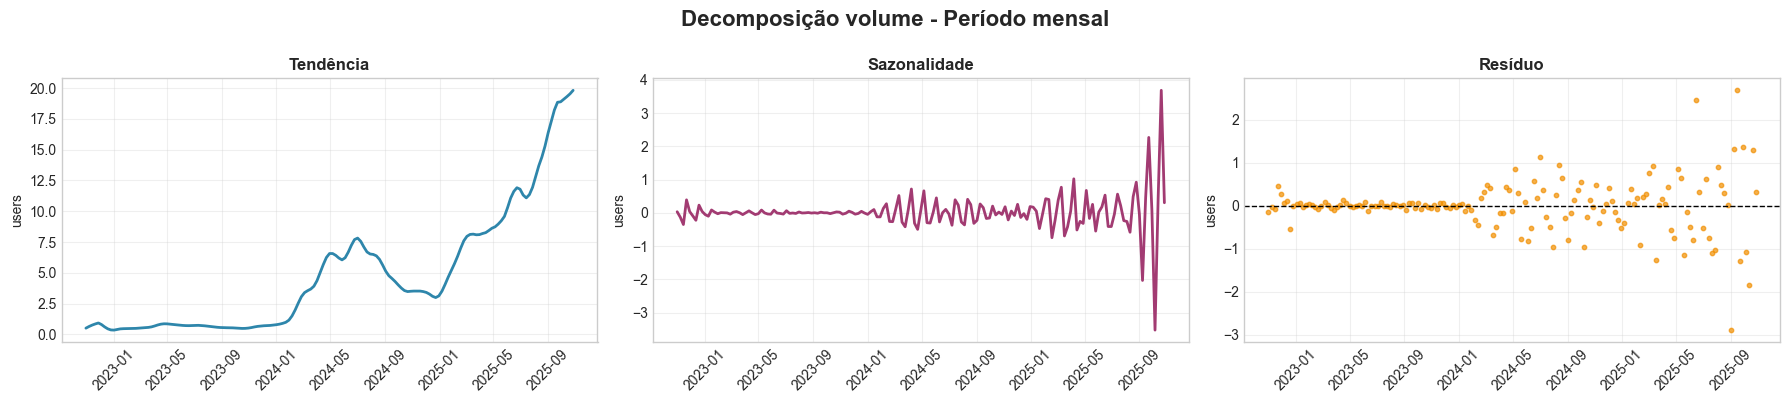

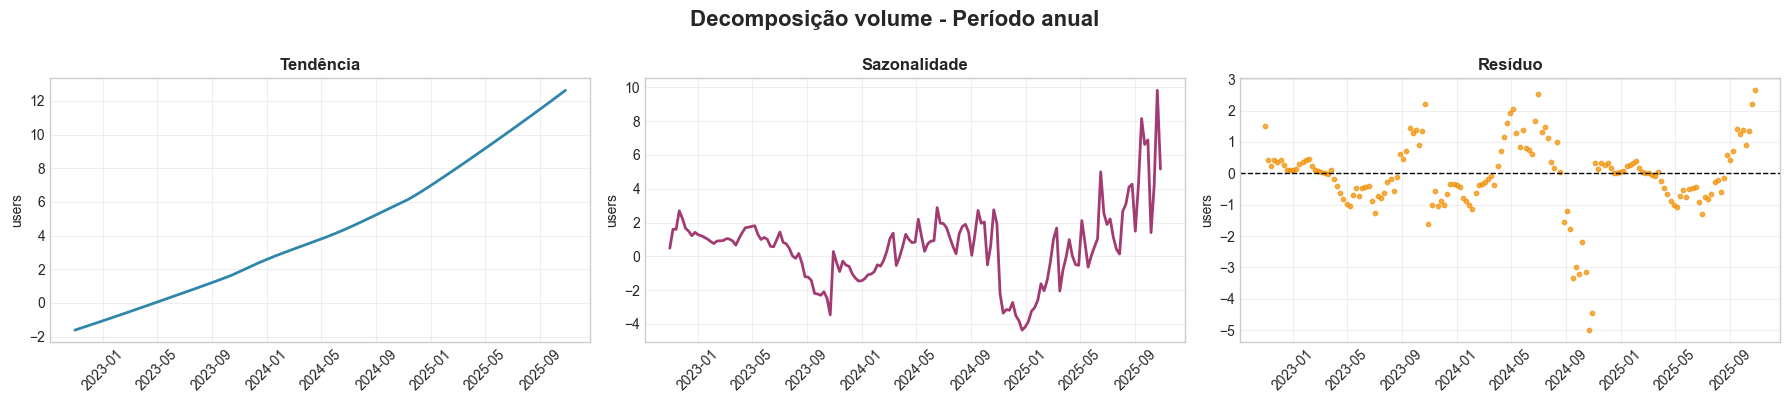

In [88]:
for period in [4, 52]:    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Decomposição mensal usando STL7
    decomp = STL(data["volume"], period=period).fit()

    # Tendência
    axes[0].plot(decomp.trend, color='#2E86AB', linewidth=2)
    axes[0].set_title(f'Tendência', fontsize=12, fontweight='bold')
    axes[0].set_ylabel(var, fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(axis='x', rotation=45)

    # Sazonalidade
    axes[1].plot(decomp.seasonal, color='#A23B72', linewidth=2)
    axes[1].set_title(f'Sazonalidade', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(var, fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)

    # Resíduo (scatter plot)
    axes[2].scatter(decomp.resid.index, decomp.resid, color='#F18F01', alpha=0.7, s=10)
    axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[2].set_title(f'Resíduo', fontsize=12, fontweight='bold')
    axes[2].set_ylabel(var, fontsize=10)
    axes[2].grid(True, alpha=0.3)
    axes[2].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Decomposição volume - Período {"mensal" if period == 4 else "anual"}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

Como podemos ver, com período semanal, a componente sazonal apresenta baixa amplitude relativa, sendo irrelevante quando comparada com a tendência. E, com período anual, embora a sazonalidade agora possua impacto significativo, os resíduos possuem uma estrutura que claramente não é ruidosa.

No entanto, na decomposição mensal, observamos ruídos com amplitude maior no final da série, quando a variável `volume` apresenta valores maiores. Isso sugere fortemente uma heterocedasticidade dos dados. Dessa forma, vamos aplicar uma transformação $\log$ nessa variável e tentar novamente realizar a decomposição STL.

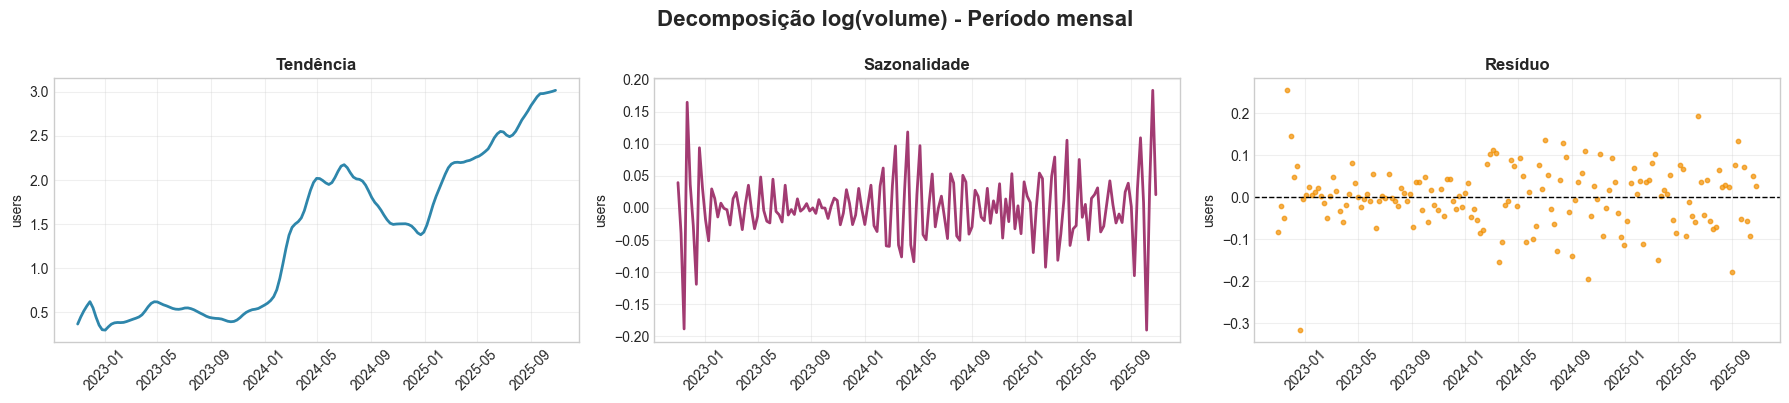

In [89]:
# Tranformação
data_log = data.copy()
data_log[f'volume_log'] = np.log1p(data["volume"])

# Decomposição mensal usando STL7
decomp = STL(data_log["volume_log"], period=4).fit()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Tendência
axes[0].plot(decomp.trend, color='#2E86AB', linewidth=2)
axes[0].set_title(f'Tendência', fontsize=12, fontweight='bold')
axes[0].set_ylabel(var, fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Sazonalidade
axes[1].plot(decomp.seasonal, color='#A23B72', linewidth=2)
axes[1].set_title(f'Sazonalidade', fontsize=12, fontweight='bold')
axes[1].set_ylabel(var, fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Resíduo (scatter plot)
axes[2].scatter(decomp.resid.index, decomp.resid, color='#F18F01', alpha=0.7, s=10)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_title(f'Resíduo', fontsize=12, fontweight='bold')
axes[2].set_ylabel(var, fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(f'Decomposição log(volume) - Período mensal', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

Agora, obtivemos um resíduo com estrutura razoavelmente aleatória, indicando o sucesso da aplicação da transformação $\log$. No entanto, a componente sazonal continua com uma amplitude descartável. Portanto, optaremos por não incluir componentes sazonais nos ajustes dos nossos modelos, mas utilizaremos a transformação logarítmica da variável target.

In [90]:
data_log[f'inv_log'] = np.log1p(data["inv"])
data_log[f'users_log'] = np.log1p(data["users"])

### 1.4. Correlações com as covariáveis

Em seguida, faremos gráficos de dispersão da variável target `volume` contra as covariáveis `inv` e `users`, tanto com a target original quanto com a versão transformada por $\log$, para avaliar a significância das covariáveis para explicar a `volume`.

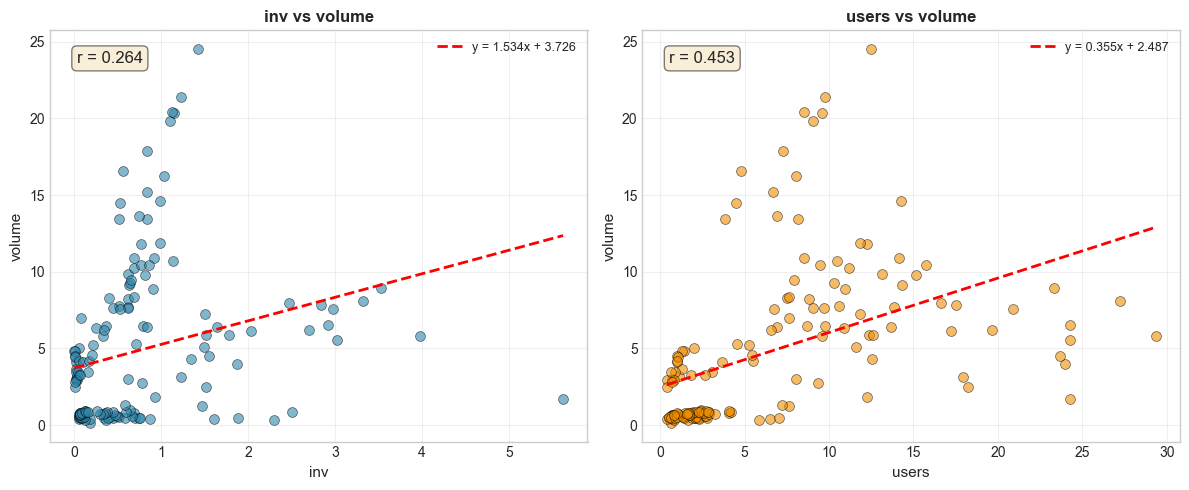

In [91]:
# Scatter plots com linha de tendência (volume original)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pairs = [('inv', 'volume'), ('users', 'volume')]
pair_colors = ['#2E86AB', '#F18F01', '#A23B72']

for ax, (var1, var2), color in zip(axes, pairs, pair_colors):
    # Scatter
    ax.scatter(data_log[var1], data_log[var2], alpha=0.6, s=50, color=color, edgecolors='black', linewidth=0.5)

    # Linha de tendência
    z = np.polyfit(data_log[var1], data_log[var2], 1)
    p = np.poly1d(z)
    ax.plot(data_log[var1].sort_values(), p(data_log[var1].sort_values()),
            "r--", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

    # Correlação
    corr = data_log[var1].corr(data_log[var2])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_xlabel(var1, fontsize=11)
    ax.set_ylabel(var2, fontsize=11)
    ax.set_title(f'{var1} vs {var2}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

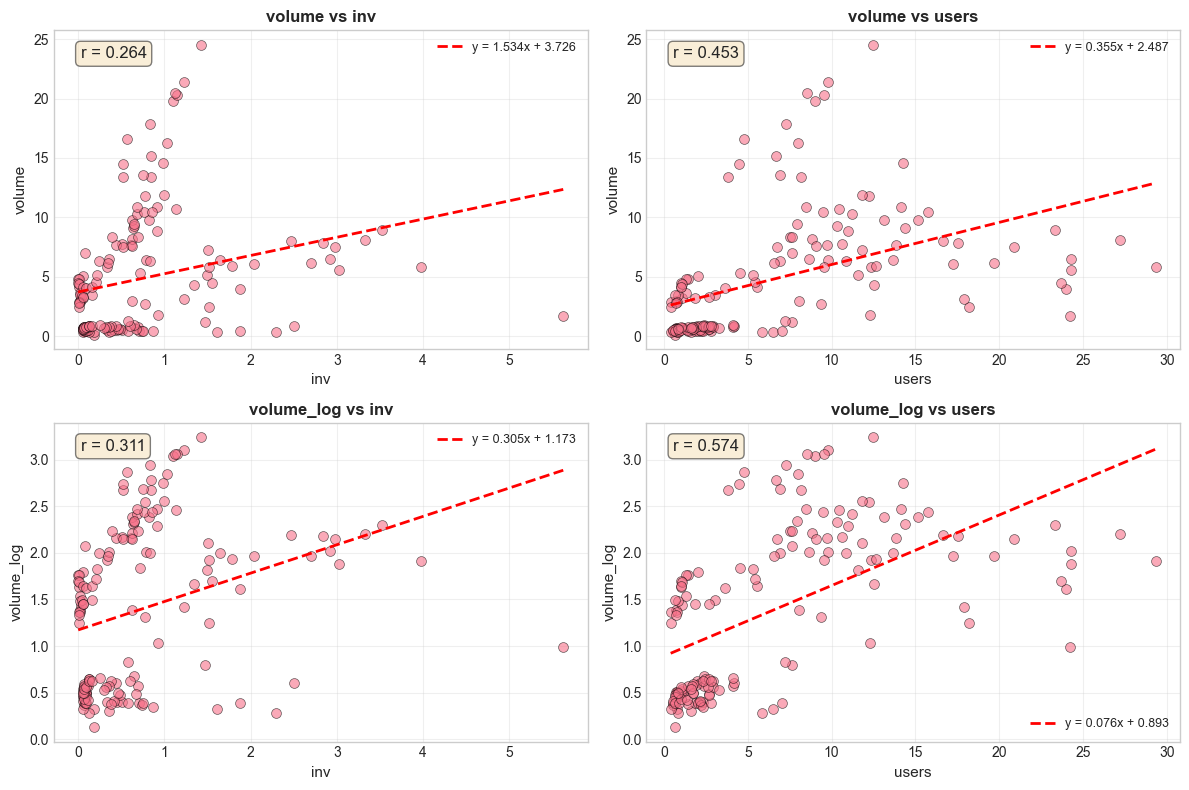

In [92]:
# Scatter plots com linha de tendência (volume original)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pairs = [('inv', 'volume'), ('users', 'volume'), ('inv', 'volume_log'), ('users', 'volume_log')]

for i, (var1, var2) in enumerate(pairs):
    ax = axes[i // 2, i % 2]
    
    # Scatter
    ax.scatter(data_log[var1], data_log[var2], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    # Linha de tendência
    z = np.polyfit(data_log[var1], data_log[var2], 1)
    p = np.poly1d(z)
    ax.plot(data_log[var1].sort_values(), p(data_log[var1].sort_values()),
            "r--", linewidth=2, label=f'y = {z[0]:.3f}x + {z[1]:.3f}')

    # Correlação
    corr = data_log[var1].corr(data_log[var2])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_xlabel(var1, fontsize=11)
    ax.set_ylabel(var2, fontsize=11)
    ax.set_title(f'{var2} vs {var1}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Pode-se ver que ambas as variáveis possuem certa correlação com a variável target, indicando potencial preditivo. Entretanto, nas versões com a target original (linha superior), os pontos se distanciam consideravelmente da reta ajustada à medida que o valor das variáveis aumenta, indicando a presença de heterocedasticidade. Com isso, as versões com transformação logarítmica da `volume` apresentam uma correlação mais regular e significativa, mais uma vez reforçando a necessidade da utilização dessa transformação.

Além disso, os valores das covariáveis `inv` e `users` também aparentam ter uma distribuição assimétrica à direita, com uma grande concentração de pontos em valores baixos e uma escassez de registros com valores maiores. Isso sugere a aplicação de transformações logarítmicas também a essas covariáveis, o que será considerado no ajuste dos modelos TSLM na seção 2.

### 1.5. Correlação cruzada

Por fim, vamos analisar a correlação cruzada entre a variável `volume` já com transformação logarítmica e as covariáveis `inv` e `users`, com o objetivo de verificar o imediatismo do impacto dos valores dessas covariáveis na variável target ou a amplitude de seu lag.

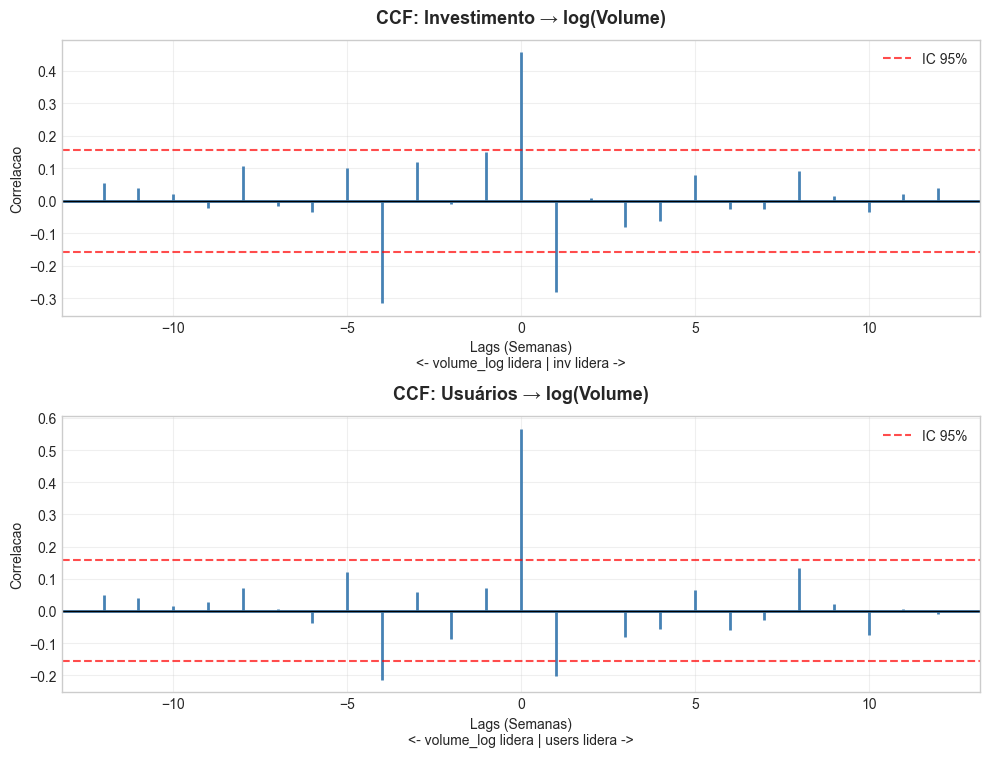

In [93]:
data["volume_log"] = np.log(data["volume"])

data_diff = data.diff().dropna()

max_lag = 12
pares = [
    ('inv', 'volume_log', 'Investimento → log(Volume)'),
    ('users', 'volume_log', 'Usuários → log(Volume)'),
]

fig, axes = plt.subplots(len(pares), 1, figsize=(10, 8))
plt.subplots_adjust(hspace=0.5)

for i, (var_x, var_y, titulo) in enumerate(pares):
    ax = axes[i]

    temp_df = data_diff[[var_x, var_y]].dropna()
    x = temp_df[var_x].values
    y = temp_df[var_y].values

    lags_plot, corrs_plot, _, _ = ax.xcorr(
        x, y,
        maxlags=max_lag,
        usevlines=True,
        normed=True,
        lw=2,
        color='steelblue'
    )

    n = len(x)
    limite = 1.96 / np.sqrt(n)
    ax.axhline(limite, color='red', linestyle='--', alpha=0.7, label='IC 95%')
    ax.axhline(-limite, color='red', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linewidth=1)

    ax.set_title(f"CCF: {titulo}", fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel("Correlacao")
    ax.set_xlabel(f"Lags (Semanas)\n<- {var_y} lidera | {var_x} lidera ->")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

    sig_mask = np.abs(corrs_plot) > limite
    lags_sig = lags_plot[sig_mask]
    corrs_sig = corrs_plot[sig_mask]

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Observando o lado direito desses gráficos, é possível ver que, tanto para `inv` quanto para `users`, existe uma alta correlação imediata entre elas e a `volume_log`, com valores significativos nos lags 0 e 1. No entanto, como não saberemos os valores dessas covariáveis na exata semana da qual queremos prever `volume`, então consideraremos aqui apenas o lag 1. Além disso, para a covariável `users`, podemos ver uma interação significativa entre ela e a variável target com 8 semanas de lag (2 meses), o que levanta a hipótese de um ciclo de maturação ou conversão tardia da base de usuários. Levaremos isso em consideração ao testar ajustes de modelos na próxima seção.

## 2. Modelagem TSLM

Nesta seção, realizaremos o ajuste de modelos lineares simples (sem autoregressão), utilizando as covariáveis disponíveis e algumas combinações e transformações derivadas dos resultados da seção anterior.

Inicialmente, vale ressaltar que todos os modelos ajustados a seguir serão baseados na transformação logarítmica da variável target `volume`, dadas as diversas evidências de heterocedasticidade apresentadas anteriormente.

Serão ajustados 3 modelos lineares para séries temporais:

- **Simples**: $\log$(`volume`) ~ `inv_lag_1` + `users_lag_1` + `users_lag_8`
- **Tendência**: $\log$(`volume`) ~ `inv_lag_1` + `users_lag_1` + `users_lag_8` + `trend`
- **Elasticidade**: $\log$(`volume`) ~ $\log$(`inv_lag_1`) + $\log$(`users_lag_1`) + $\log$(`users_lag_8`) + `trend`

Assim, iniciamos com um modelo simples, contendo apenas as covariáveis disponíveis e seus respectivos lags analisados na seção 1.5. Em seguida, adicionamos a componente de tendência, visível como relevante na seção 1.2. Por fim, testamos uma abordagem $\log$-$\log$, aplicando uma transformação logarítmica também nas covariáveis e em seus lags, como sugerido na seção 1.4.

In [96]:
# Criando as colunas derivadas
data["inv"] = data["inv"].shift(1)
data["users"] = data["users"].shift(1)
data["log_inv"] = np.log1p(data["inv"])
data["log_users"] = np.log1p(data["users"])
data["users_lag_8"] = data["users"].shift(7)
data["users_log_lag_8"] = np.log1p(data["users_lag_8"])
data["trend"] = np.arange(len(data))

data.dropna(inplace=True)

# Separando as covariáveis
X = data.drop('volume', axis=1)
y = data['volume']

# Aplicando o log na target
y_log = np.log1p(y)

data.head()

,volume,inv,users,volume_log,log_inv,log_users,users_lag_8,users_log_lag_8,trend
week,,,,,,,,,
2023-02-20,0.41,0.701953,2.042,-0.891598,0.531776,1.112515,0.655,0.503801,8
2023-02-27,0.47,0.745329,2.219,-0.755023,0.556943,1.169071,0.778,0.575489,9
2023-03-06,0.62,0.870134,2.310,-0.478036,0.626010,1.196948,0.808,0.592221,10
2023-03-13,0.60,0.756382,2.785,-0.510826,0.563256,1.331046,1.641,0.971158,11
2023-03-20,0.51,0.665072,2.660,-0.673345,0.509869,1.297463,2.323,1.200868,12


In [97]:
log_models = {}

predictions = {}
models = {}

models_cols = {
    "Covars": ["inv", "users", "users_lag_8"],
    "Covars + Trend": ["trend", "inv", "users", "users_lag_8"],
    "Log Covars + Trend": ["trend", "log_inv", "log_users", "users_log_lag_8"],
}

results = {}

for model_name, cols in models_cols.items():
    X_model = sm.add_constant(X[cols])

    model = sm.OLS(y_log, X_model).fit()
    log_models[model_name] = model

    metrics = {}

    metrics["Adjusted R²"] = log_models[model_name].rsquared_adj
    metrics["AIC"] = log_models[model_name].aic
    metrics["BIC"] = log_models[model_name].bic

    results[model_name] = metrics

results_df = pd.DataFrame(results).T
display(results_df.sort_values(by="Adjusted R²", ascending=False))

,Adjusted R²,AIC,BIC
Log Covars + Trend,0.955483,-80.070407,-65.326607
Covars + Trend,0.934073,-24.703260,-9.959461
Covars,0.509624,257.263275,269.058314


Como podemos ver, a simples adição de uma componente de tendência melhora muito o desempenho do modelo, aumentando em aproximadamente 0.43 o valor do coeficiente R² ajustado em relação ao modelo sem ela, o que demonstra a presença de tendência determinística na variável target.

Em seguida, fica claro que o melhor modelo dentre esses é o modelo de elasticidade, com os logaritmos das covariáveis, que apresenta desempenho superior em todas as métricas consideradas. 